# IS 4487 Assignment 7: Data Transformation with Airbnb Listings

In this assignment, you will:
- Load the Airbnb dataset you cleaned in Assignment 6
- Apply data transformation techniques like scaling, binning, encoding, and feature creation
- Make the dataset easier to use for tasks like pricing analysis, guest segmentation, or listing recommendations
- Practice writing up your analysis clearly so a business audience — like a host, marketing manager, or city partner — could understand it

## Why This Matters

Airbnb analysts, hosts, and city partners rely on clean and well-structured data to make smart decisions. Whether they’re adjusting prices, identifying high-performing listings, or designing better guest experiences, they need data that’s transformed, organized, and ready for use.

This assignment helps you practice that kind of real-world thinking: taking messy real data and getting it ready for action.

<a href="https://colab.research.google.com/github/vandanara/UofUtah_IS4487/blob/main/Assignments/assignment_07_data_transformation.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.

## 1. Setup and Load Your Data

You'll be working with the `cleaned_airbnb_data.csv` file you exported from Assignment 6.

📌 In Google Colab:
- Click the folder icon on the left sidebar
- Use the upload button to add your CSV file to the session
- Then use the code block below to read it into your notebook

Before getting started, make sure you import the libraries you'll need for this assignment:
- `pandas`, `numpy` for data manipulation
- `matplotlib.pyplot`, `seaborn` for visualizations


In [1]:

# Import necessary libraries 🔧
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv("cleaned_airbnb_data.csv")

## 2. Check for Skew in a Numeric Column

Business framing:  

Airbnb listings can have a wide range of values for things like price, availability, or reviews. These kinds of distributions can be hard to visualize, summarize, or model.

Choose one **numeric column** that appears skewed and do the following:
- Plot a histogram
- Apply a transformation (e.g., log or other method)
- Plot again to compare


### In Your Response:
1. What column did you examine?
2. What transformation did you try, and why?
3. How did the transformed version help make the data more usable for analysis or stakeholder review?



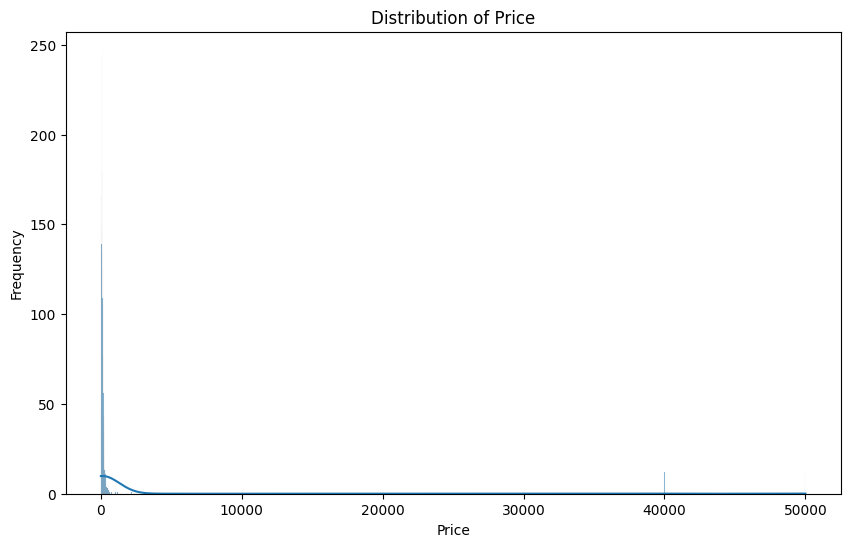

In [3]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True)
plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

In [4]:
df['price_log'] = np.log1p(df['price'])

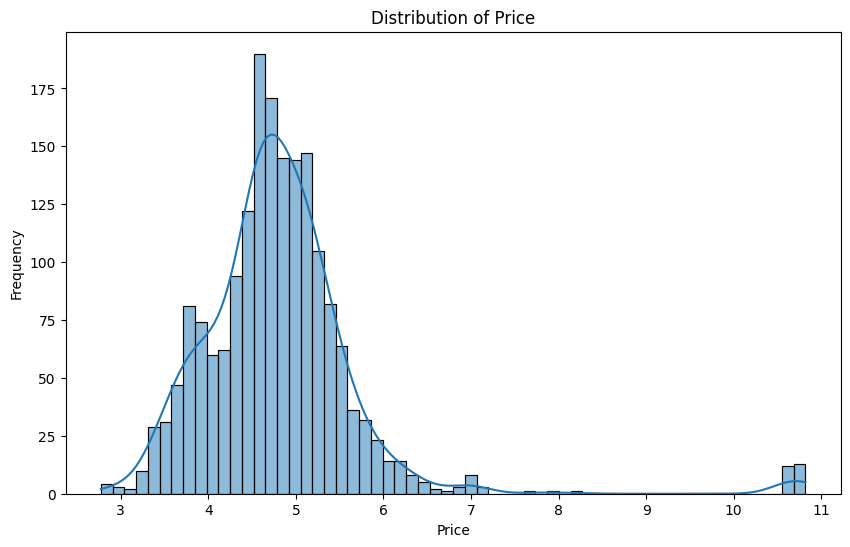

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price_log'], kde=True)
plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

### ✍️ Your Response: 🔧
1. I examined the price column.

2. I tried a log transformation first because I am most familiar with it and thought that it would be easiest for me to understand the data by doing so.

3. Before the transformation the data was incomprehensible. You couldn't tell what was going on at all. After the transformation we are able to actually understand the general shape and distribution of our data making it usable.


## 3. Scale Two Numeric Columns

Business framing:

If an analyst wanted to compare listing price to number of nights required, or create a model that weighs both, those values need to be on a similar scale.

Follow these steps:
- Pick two numeric columns with different value ranges (e.g. one column may have a min of 0 and a max of 255; another column may have a min of 100 and a max of 400)
- Use Min-Max scaling on one column (the range should be “shrinked” down to just 0-1)
- Use Z-score Normalization (aka standardization) on the other column.
- Add 2 new columns to the dataset. These 2 new columns should be the ones you just created.

### In Your Response:
1. What two columns did you scale, and which methods did you use?
2. When might these scaled values be more useful than the originals?
3. Who at Airbnb might benefit from this transformation and why?

In [10]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Min-Max scale
min_max_scaler = MinMaxScaler()
df['price_minmax_scaled'] = min_max_scaler.fit_transform(df[['price']])

# Z-score scale
standard_scaler = StandardScaler()
df['maximum_maximum_nights_zscore_scaled'] = standard_scaler.fit_transform(df[['maximum_maximum_nights']])


In [11]:
display(df.head())

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,price_log,price_minmax_scaled,maximum_maximum_nights_zscore_scaled
0,257869,https://www.airbnb.com/rooms/257869,20250613040024,2025-06-13,previous scrape,House w/ Pool in Cultural District/close2downtown,No STR's! <br />Be my guest and enjoy everythi...,Very quiet neighborhood. <br />Tree lined stre...,https://a0.muscache.com/pictures/18939849/1e85...,1356081,...,NaN,f,1,1,0,0,2.31,NaN,NaN,1.101977
1,299748,https://www.airbnb.com/rooms/299748,20250613040024,2025-06-13,previous scrape,Rosy's Guest House,"Quiet, ground floor studio apartment in a gorg...",Gorgeous historic homes with tree lined sidew...,https://a0.muscache.com/pictures/4eead819-7ad8...,1544441,...,NaN,f,1,1,0,0,2.20,NaN,NaN,1.101977
2,912371,https://www.airbnb.com/rooms/912371,20250613040024,2025-06-13,city scrape,Stay in Ft.Worth Cultural District,"Quiet, studio, upstairs garage apartment surro...","This is a beautiful, safe, quiet neighborhood ...",https://a0.muscache.com/pictures/13577479/7098...,4895584,...,NaN,f,1,1,0,0,2.15,4.077537,0.000860,-1.314155
3,1885626,https://www.airbnb.com/rooms/1885626,20250613040024,2025-06-13,city scrape,Private bedroom in spacious home,"If you're like us, friendly Canadians, you jus...",This neighbourhood is very quiet and family or...,https://a0.muscache.com/pictures/37169857/d6f1...,7892516,...,NaN,f,1,0,1,0,0.68,3.871201,0.000640,1.101977
4,2130492,https://www.airbnb.com/rooms/2130492,20250613040024,2025-06-13,city scrape,"Charming ""attic room"" by TCU campus",Our cozy 2-story home overlooks the TCU stadiu...,"This is a wonderfully friendly old, yet lively...",https://a0.muscache.com/pictures/54799567/0f33...,826752,...,NaN,f,2,0,2,0,0.32,4.615121,0.001701,-1.454220


### ✍️ Your Response: 🔧
1. I did used min-max scale on the price column and the z-score on the maximum_maximum_nights column.

2. Price has a much larger range compared to maximum_maximum_nights by scaling them appropriately we can actually compare these values on a fair scale. Furthermore, it may be easier to identify patterns occurring by scaling.

3. Analysts or anyone looking to get a more comprehensive understanding of the data will find these columns useful allowing ease for further analysis.


## 4. Group a Numeric Column into Categories

Business framing:  

Let’s say an Airbnb marketing team wants to segment listings by review activity. They don’t want exact numbers — they just want to know if a listing has “low,” “medium,” or “high” review volume.

Follow these steps:

- Choose a numeric column that could be grouped (e.g., reviews, availability).
- You’ll want to group the values of this column into 3 or 4 bins
- Create a new column. The values of this column will be the labels: “Low”, “Medium”, and “High.” These labels should correspond to your bins.

### In Your Response:
1. What column did you group, and how many categories did you use?
2. Why might someone prefer this grouped view over raw numbers?
3. Who would this help at Airbnb, and how?


In [13]:
# Group review_scores_value into 3 bins
df['review_score_category'] = pd.qcut(df['review_scores_value'], q=3, labels=['Low', 'Medium', 'High'])

# Display the value counts for the new column in the desired order
display(df['review_score_category'].value_counts().reindex(['Low', 'Medium', 'High']))

,count
review_score_category,
Low,572
Medium,595
High,513


### ✍️ Your Response: 🔧
1. I grouped review_scores column into 3 different categories; Low, Med, High.

2. Looking at the figures in a grouping makes it much easier to interpret opposed to comparing them by just looking at the data.

3. This would benefit the marketing/sales team. By knowing which values have a high volume of ratings (especially if they are good ratings) they might use this data to promote a specific property compared to another.


## 5. Create Two New Business-Relevant Variables

Business framing:  

Stakeholders often want to know things like: What’s the cost per night? Are listings geared toward long-term stays? These kinds of features aren’t always in the dataset — analysts create them.

Follow these steps:

- Think of two new columns you can create using the data you already have.
  - One might be a ratio or interaction between columns (e.g., price ÷ nights).
  - The other might be a flag based on a condition (e.g., stays longer than 30 days).
- Add the new columns to your DataFrame.

### In Your Response:
1. What two new columns did you create?
2. Who would use them (e.g., host, manager, or platform)?
3. How could they help someone make a better decision?

In [15]:
# Create a new column for the ratio of price to the number of bedrooms
df['price_per_bedroom'] = df['price'] / df['bedrooms']

# Fill infinite values (resulting from division by zero when number_of_reviews is 0) and NaN values with 0
df['price_per_bedroom'] = df['price_per_bedroom'].replace([np.inf, -np.inf], np.nan).fillna(0)

# Display the head of the dataframe to show the new column
display(df[['price', 'bedrooms', 'price_per_bedroom']].head())

,price,bedrooms,price_per_bedroom
0,NaN,1.0,0.0
1,NaN,NaN,0.0
2,58.0,0.0,0.0
3,47.0,1.0,47.0
4,100.0,2.0,50.0


In [16]:
# Map host_response_time categories to numerical values
host_response_time_mapping = {
    'within an hour': 1,
    'within a few hours': 2,
    'within a day': 3,
    'a few days or more': 4
}
df['host_response_time_numeric'] = df['host_response_time'].map(host_response_time_mapping)

# Create a new column for the ratio of review score to host response time (using the numeric mapping)
# Add a small epsilon to the denominator to avoid division by zero
df['review_score_per_response_time'] = df['review_scores_value'] / (df['host_response_time_numeric'] + 1e-6)

# Fill infinite values and NaN values with 0
df['review_score_per_response_time'] = df['review_score_per_response_time'].replace([np.inf, -np.inf], np.nan).fillna(0)

# Display the head of the dataframe to show the new column
display(df[['review_scores_value', 'host_response_time', 'host_response_time_numeric', 'review_score_per_response_time']].head())

,review_scores_value,host_response_time,host_response_time_numeric,review_score_per_response_time
0,4.92,NaN,NaN,0.000000
1,4.96,within an hour,1.0,4.959995
2,4.83,within an hour,1.0,4.829995
3,4.96,within an hour,1.0,4.959995
4,5.00,NaN,NaN,0.000000


### ✍️ Your Response: 🔧 🔧
1. I created a price per bedroom column and a review score per response time column.

2. A customer might find the price per bedroom column most useful, while the host may find the review score per response time useful.

3. If hosts find that a quicker response leads to higher review scores they might be more motivated to respond quickly. On the flip side there are many things that would go into the price (ex. Location, amenities) but for someone on a budget or with a lot of people they may be able to understand how expensive somewhere is based solely on the number of rooms.



## 6. Encode a Categorical Column

Business framing:  

Let’s say you’re helping the Airbnb data science team build a model to predict booking rates. Categorical columns like `room_type`, `neighbourhood`, or `cancellation_policy` can’t be used in models unless they’re converted to numbers.

- Choose one categorical column from your dataset (e.g., room type or neighborhood group)
- Decide on an encoding method:
  - Use one-hot encoding for nominal (unordered) categories
  - Use ordinal encoding (a ranking) only if the categories have a clear order
- Apply the encoding using `pandas` or another tool
- Add the new encoded column(s) to your DataFrame

### ✍️ In your markdown:
1. What column did you encode and why?
2. What encoding method did you use?
3. How could this transformation help a pricing model, dashboard, or business report?



In [17]:
# Apply one-hot encoding to the 'property_type' column
property_type_encoded = pd.get_dummies(df['property_type'], prefix='property')

# Concatenate the new encoded columns with the original DataFrame
df = pd.concat([df, property_type_encoded], axis=1)

# Display the head of the dataframe to show the new columns
display(df.head())

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,property_Private room in home,property_Private room in loft,property_Private room in rental unit,property_Private room in serviced apartment,property_Private room in townhouse,property_Private room in villa,property_Room in boutique hotel,property_Room in hotel,property_Shared room in home,property_Tiny home
0,257869,https://www.airbnb.com/rooms/257869,20250613040024,2025-06-13,previous scrape,House w/ Pool in Cultural District/close2downtown,No STR's! <br />Be my guest and enjoy everythi...,Very quiet neighborhood. <br />Tree lined stre...,https://a0.muscache.com/pictures/18939849/1e85...,1356081,...,False,False,False,False,False,False,False,False,False,False
1,299748,https://www.airbnb.com/rooms/299748,20250613040024,2025-06-13,previous scrape,Rosy's Guest House,"Quiet, ground floor studio apartment in a gorg...",Gorgeous historic homes with tree lined sidew...,https://a0.muscache.com/pictures/4eead819-7ad8...,1544441,...,False,False,False,False,False,False,False,False,False,False
2,912371,https://www.airbnb.com/rooms/912371,20250613040024,2025-06-13,city scrape,Stay in Ft.Worth Cultural District,"Quiet, studio, upstairs garage apartment surro...","This is a beautiful, safe, quiet neighborhood ...",https://a0.muscache.com/pictures/13577479/7098...,4895584,...,False,False,False,False,False,False,False,False,False,False
3,1885626,https://www.airbnb.com/rooms/1885626,20250613040024,2025-06-13,city scrape,Private bedroom in spacious home,"If you're like us, friendly Canadians, you jus...",This neighbourhood is very quiet and family or...,https://a0.muscache.com/pictures/37169857/d6f1...,7892516,...,True,False,False,False,False,False,False,False,False,False
4,2130492,https://www.airbnb.com/rooms/2130492,20250613040024,2025-06-13,city scrape,"Charming ""attic room"" by TCU campus",Our cozy 2-story home overlooks the TCU stadiu...,"This is a wonderfully friendly old, yet lively...",https://a0.muscache.com/pictures/54799567/0f33...,826752,...,True,False,False,False,False,False,False,False,False,False


### ✍️ Your Response: 🔧
1. I encoded the property type column,
2. I used one-hot encoding as there isn't a clear order.
3. By filtering by property type you would begin to understand which properties are the most common, providing the greatest return, etc. You can use these columns to develop a price model for each type.

## 7. Reflection

You’ve applied the same kinds of transformation techniques used in real Airbnb analytics projects — from pricing engines to host tools to tourism dashboards.

Now step back and reflect.

### In Your Response:
1. What transformation step felt most important or interesting?
2. Which of your changes would be most useful to a host, analyst, or city planner?
3. If you were going to build a tool or dashboard, what would you do next with this data?
4. How does this relate to your customized learning outcome you created in canvas?



### ✍️ Your Response: 🔧

1. I felt that combining columns was the most useful as you can easily compare two separate variables.

2. Once again combining columns such as review score and response time a host might find this extremely useful.

3. I would run additional analysis regarding price and property type. You can also combine this with property type and the price per room column.

4. I wanted to learn more about predictive analytics and understanding which properties have the greatest returns. I am enhancing my skills in learning to predict revenue.




## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [18]:
!jupyter nbconvert --to html "assignment_07_PetersonSteven.ipynb"

[NbConvertApp] Converting notebook assignment_07_PetersonSteven.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 410421 bytes to assignment_07_PetersonSteven.html
